In [23]:
from generate_utils import load_GraphModel, load_BiLSTMModel
from models_graph import HarmonicGraphEncoder
import torch
import numpy as np
import pickle
from tqdm import tqdm
from GridMLM_tokenizers import CSGridMLMTokenizer
from graph_utils import get_graph_embeddings_from_string_with_model, get_bilstm_embeddings_from_string_with_model, graph_from_string, compare_heterodata

In [24]:
tokenizer = CSGridMLMTokenizer(
    fixed_length=80,
    quantization='4th',
    intertwine_bar_info=True,
    trim_start=False,
    use_pc_roll=True,
    use_full_range_melody=False
)

In [25]:
device_name = 'cuda:0'
device = torch.device(device_name)

graph_model_path = 'saved_models/LoRA/graph/graph_model_jnhw.pt'
# graph_model_path = 'saved_models/LoRA/graph/graph_model_h.pt'
# bilstm_model_path = 'saved_models/bilstm/bilstm_model.pt'

In [26]:
graph_model = load_GraphModel(graph_model_path, device)
# graph_model_LoRA = graph_model = HarmonicGraphEncoder(participation_edge_dim=5)
# graph_model_LoRA.to(device)
# bilstm_model = load_BiLSTMModel(bilstm_model_path, device)

In [27]:
graph_model.eval()
# bilstm_model.eval()

HarmonicGraphEncoder(
  (pitch_embedding): Embedding(12, 256)
  (pitch_proj): Linear(in_features=256, out_features=256, bias=True)
  (event_proj): Linear(in_features=1, out_features=256, bias=True)
  (participation_mpnn): ParticipationMPNN()
  (temporal_mpnn): TemporalMPNN()
  (to_latent): Linear(in_features=256, out_features=512, bias=True)
)

In [28]:
datasets = {
    'gjt': {'path': 'data/gjt_test.pkl', 'dataset': None},
    # 'hook': {'path': 'data/hook_test.pkl', 'dataset': None},
    'nott': {'path': 'data/nott_test.pkl', 'dataset': None},
    # 'wiki': {'path': 'data/wiki_test.pkl', 'dataset': None}
}

In [29]:
for k, v in datasets.items():
    print(f'loading {k}')
    with open(v['path'], 'rb') as f:
        d = pickle.load(f)
    v['dataset'] = d

loading gjt
loading nott


In [30]:
graph_embeddings = []
# bilstm_embeddings = []
metadata = []

for k,v in datasets.items():
    for i, d in tqdm(enumerate(v['dataset'])):
        g = d['graph_ready_object']
        bar_objects = g.bar_objects
        for bar_start in range(len(bar_objects)-2):
            bar_end = bar_start + 2
            # graph
            g.make_graph_of_segment(bar_start, bar_end)
            z_graph = graph_model(g.segment_graph.to(device))
            graph_embeddings.append(
                z_graph.detach().cpu().numpy()
            )
            # # bilstm
            # g.make_bilstm_seq_of_segment(bar_start, bar_end)
            # segment_bilstm = g.segment_bilstm.unsqueeze(0)
            # lengths = torch.tensor(segment_bilstm.shape[1], dtype=int).unsqueeze(0)
            # z_bilstm = bilstm_model(segment_bilstm.to(device), lengths.to(device))
            # bilstm_embeddings.append(
            #     z_bilstm.detach().cpu().numpy()
            # )
            # make string of chord symbols
            chords_str = f'{k}_{i}_[{bar_start}, {bar_end}]<br>'
            for bar_idx in range(bar_start, bar_end):
                chords_str += 'b_'
                for chord in bar_objects[bar_idx].chord_objects:
                    mel_pcs = [r.tolist() for pcs in chord.melody_pcs for r in pcs]
                    mel_pcs = list( set(mel_pcs) )
                    chords_str += tokenizer.ids_to_tokens[chord.chord_id] + '_@' + str(len(chord.bar_positions)) + \
                                    '_m' + repr(mel_pcs) + '<br>'
            metadata.append({
                'dataset': k,
                'piece_idx': i,
                'bar_start': bar_start,
                'bar_end': bar_end,
                'chords': chords_str
            })

graph_embeddings = np.vstack(graph_embeddings)
# bilstm_embeddings = np.vstack(bilstm_embeddings)

28it [00:01, 27.32it/s]
45it [00:01, 25.78it/s]


In [31]:
print(graph_embeddings.shape)
# print(bilstm_embeddings.shape)

(1054, 512)


In [32]:
print(metadata[100])

{'dataset': 'gjt', 'piece_idx': 7, 'bar_start': 8, 'bar_end': 10, 'chords': 'gjt_7_[8, 10]<br>b_F:maj7_@2_m[0, 9]<br>E:min7_@2_m[9, 11, 4, 7]<br>b_F:maj7_@2_m[9]<br>E:min7_@2_m[9]<br>'}


In [33]:
# in_seq_1 = 'b_C:maj_@2_m[0,4,9];A:7_@2_m[1,4]b_D:min_@2_m[2,5,7];G:7_@2_m[5,9,11]'
# in_seq_2 = 'b_C:maj_@2_m[0,4];A:7_@2_m[1,7]b_D:min_@2_m[2,5,9];G:7_@2_m[5,9,2]'
# in_seq_3 = 'b_A:7_@2_m[1,4];D:min_@2_m[2,5,7]b_G:7_@2m[5,9,11];C:maj_@2_m[0,4,9]'
# in_seq_4 = 'b_D:min_@2_m[2,5,7];G:7_@2_m[5,9,11]b_C:maj_@2_m[0,4,9];A:7_@2_m[1,4]'

# in_seq_1 = 'b_C:maj_@2_m[0,4,9];A:7_@2_m[1,4]b_D:min_@4_m[2,5,7]'
# in_seq_2 = 'b_C:maj_@2_m[0,4];A:7_@2_m[1,7]b_D:min_@4_m[2,5,9]'
# in_seq_3 = 'b_A:7_@2_m[1,4];D:min_@2_m[2,5,7]b_G:7_@4m[5,9,11]'
# in_seq_4 = 'b_D:min_@0_m[2,5,7];G:7_@2_m[5,9,11]b_C:maj_@0_m[0,4,9]'

# in_seq_4 = 'b_E:min7_@2_m[2,7];D#:7_@2_m[7]b_G#:maj7_@2_m[7];G:7_@2_m[7]'
# in_seq_4 = 'b_E:min7_@2_m[2,7];D#:7_@2_m[7]b_G#:maj7_@2_m[7,1];G:7_@2_m[7]'
# in_seq_4 = 'b_A:min_@2_m[7];D#:7_@2_m[7]b_G#:maj7_@2_m[7];G:7_@2_m[7]'

# in_seq_1 = 'b_G:7_@2;C:maj_@2'
# in_seq_2 = 'b_G:9_@2;C:maj_@2'
# in_seq_3 = 'b_B:hdim7_@2;C:maj_@2'
# in_seq_4 = 'b_C#:7_@2;C:maj_@2'

# in_seq_1 = 'b_C:7_@2;F:maj_@2'
# in_seq_2 = 'b_C:9_@2;F:maj_@2'
# in_seq_3 = 'b_E:hdim7_@2;F:maj_@2'
# in_seq_4 = 'b_F#:7_@2;F:maj_@2'

# in_seq_1 = 'b_G:7_@2;C:maj7_@2'
# in_seq_2 = 'b_C:7_@2;F:maj7_@2'
# in_seq_3 = 'b_F:7_@2;A#:maj7_@2'
# in_seq_4 = 'b_A#:7_@2;D#:maj7_@2'

# in_seq_1 = 'b_B:7_@2;E:maj7_@2'
# in_seq_2 = 'b_E:7_@2;A:maj7_@2'
# in_seq_3 = 'b_A:7_@2;D:maj7_@2'
# in_seq_4 = 'b_D:7_@2;G:maj7_@2'

in_seq_1 = 'b_G:7_@2;C:maj7_@2'
in_seq_2 = 'b_G:7_@2;D:maj7_@2'
in_seq_3 = 'b_G:sus4_@4b_G:sus4@4'
in_seq_4 = 'b_A:min11_@4b_A:min11_@4'

# in_seq_1 = 'b_D:7(b9)_@2;G:maj_@2'
# in_seq_2 = 'b_D:9_@2;G:maj_@2'
# in_seq_3 = 'b_F#:hdim7_@2;G:maj_@2'
# in_seq_4 = 'b_G#:7_@2;G:maj_@2'

# in_seq_1 = 'b_C:maj7_@0;F:maj_@2'
# in_seq_2 = 'b_C:maj9_@0;F:maj_@2'
# in_seq_3 = 'b_E:min7_@0;F:maj_@2'
# in_seq_4 = 'b_A:min7_@0;F:maj_@2'

# in_seq_1 = 'b_D:min7_@0;G:7_@2'
# in_seq_2 = 'b_D:min9_@0;G:7_@2'
# in_seq_3 = 'b_F:maj7_@0;G:7_@2'
# in_seq_4 = 'b_A:min7_@0;G:7_@2'

# in_seq_1 = 'b_E:min7_@0;A:7_@2'
# in_seq_2 = 'b_E:min9_@0;A:7_@2'
# in_seq_3 = 'b_G:maj7_@0;A:7_@2'
# in_seq_4 = 'b_B:min7_@0;A:7_@2'

# in_seq_1 = 'b_F#:min7_@0;B:7_@2'
# in_seq_2 = 'b_F#:min9_@0;B:7_@2'
# in_seq_3 = 'b_A:maj7_@0;B:7_@2'
# in_seq_4 = 'b_C#:min7_@0;B:7_@2'

# in_seq_1 = 'b_B:min7_@0;E:7_@2'
# in_seq_2 = 'b_B:min9_@0;E:7_@2'
# in_seq_3 = 'b_D:maj7_@0;E:7_@2'
# in_seq_4 = 'b_F#:min7_@0;E:7_@2'

# in_seq_1 = 'b_B:min7_@0b_E:7_@0'
# in_seq_2 = 'b_B:min9_@0b_E:7_@0'
# in_seq_3 = 'b_D:maj7_@0b_E:7_@0'
# in_seq_4 = 'b_F#:min7_@0b_E:7_@0'

y_graph_1 = get_graph_embeddings_from_string_with_model(in_seq_1, graph_model)
y_graph_2 = get_graph_embeddings_from_string_with_model(in_seq_2, graph_model)
y_graph_3, m3 = get_graph_embeddings_from_string_with_model(in_seq_3, graph_model, return_mel_harm=True)
y_graph_4, m4 = get_graph_embeddings_from_string_with_model(in_seq_4, graph_model, return_mel_harm=True)

# y_bilstm_1 = get_bilstm_embeddings_from_string_with_model(in_seq_1, bilstm_model)
# y_bilstm_2 = get_bilstm_embeddings_from_string_with_model(in_seq_2, bilstm_model)
# y_bilstm_3 = get_bilstm_embeddings_from_string_with_model(in_seq_3, bilstm_model)
# y_bilstm_4 = get_bilstm_embeddings_from_string_with_model(in_seq_4, bilstm_model)

G:7 in vocab as: 216
C:maj7 in vocab as: 14
G:7 in vocab as: 216
D:maj7 in vocab as: 72
G:sus4 in vocab as: 214
unrecognized chord symbol G:sus4@4
A:min11 in vocab as: 285
A:min11 in vocab as: 285


In [34]:
m3.print_info()

Number of bars: 2
Segment bar range: [0, 2)
Segment graph features:
HeteroData(
  pitch={ x=[12, 12] },
  event={
    num_nodes=1,
    x=[1, 1],
  },
  (pitch, participates, event)={
    edge_index=[2, 3],
    edge_attr=[3, 5],
  },
  (event, next, event)={
    edge_index=[2, 0],
    edge_attr=[0],
  }
)
Segment graph bars:
Bar 1:
Bar token positions: [2, 2]
Number of chord objects in bar: 1
Chord object 1:
Chord label: G:sus4
Pitch classes: [0, 2, 7]
Root: 7
Chord ID: 214
Bar Positions: [0, 1]
Token Positions: [2, 2]
Graph Features:
tensor([[0., 0., 0., 0., 1.],
        [0., 0., 1., 0., 0.],
        [1., 0., 0., 0., 0.]])
BiLSTM Features
tensor([1., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0.])
Bar 2:
Bar token positions: []
Number of chord objects in bar: 0
Bar 1:
Bar token positions: [2, 2]
Number of chord objects in bar: 1
Chord object 1:
Chord label: G:sus4
Pitch classes: [0, 2, 7]
Root: 7
Chord ID: 214
Bar Positions: [0, 1]
Token Positions: [2, 2]
Graph Features:
tensor([[0., 0., 

In [35]:
m4.print_info()

Number of bars: 2
Segment bar range: [0, 2)
Segment graph features:
HeteroData(
  pitch={ x=[12, 12] },
  event={
    num_nodes=2,
    x=[2, 1],
  },
  (pitch, participates, event)={
    edge_index=[2, 12],
    edge_attr=[12, 5],
  },
  (event, next, event)={
    edge_index=[2, 1],
    edge_attr=[1, 6],
  }
)
Segment graph bars:
Bar 1:
Bar token positions: [2, 2]
Number of chord objects in bar: 1
Chord object 1:
Chord label: A:min11
Pitch classes: [0, 2, 4, 7, 9, 11]
Root: 9
Chord ID: 285
Bar Positions: [0, 1]
Token Positions: [2, 2]
Graph Features:
tensor([[0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 1.],
        [0., 0., 1., 0., 0.],
        [0., 0., 0., 1., 0.],
        [1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1.]])
BiLSTM Features
tensor([1., 0., 1., 0., 1., 0., 0., 1., 0., 1., 0., 1.])
Bar 2:
Bar token positions: [2, 2]
Number of chord objects in bar: 1
Chord object 1:
Chord label: A:min11
Pitch classes: [0, 2, 4, 7, 9, 11]
Root: 9
Chord ID: 285
Bar Positions: [0, 1]
Token

In [36]:
cos = torch.nn.CosineSimilarity()
print(cos(y_graph_3, y_graph_4))

tensor([0.9984], device='cuda:0')


In [37]:
from sklearn.decomposition import PCA

In [38]:
pca_graph = PCA(n_components=2)
# pca_bilstm = PCA(n_components=2)

In [39]:
y_graph = pca_graph.fit_transform(graph_embeddings)
# y_bilstm = pca_bilstm.fit_transform(bilstm_embeddings)

In [40]:
# transform new points
new_graph = np.vstack([
    y_graph_1.detach().cpu().numpy(),
    y_graph_2.detach().cpu().numpy(),
    y_graph_3.detach().cpu().numpy(),
    y_graph_4.detach().cpu().numpy(),
])

# new_bilstm = np.vstack([
#     y_bilstm_1.detach().cpu().numpy(),
#     y_bilstm_2.detach().cpu().numpy(),
#     y_bilstm_3.detach().cpu().numpy(),
#     y_bilstm_4.detach().cpu().numpy(),
# ])

new_graph_2d = pca_graph.transform(new_graph)
# new_bilstm_2d = pca_bilstm.transform(new_bilstm)

In [41]:
# print(y_graph.shape, y_bilstm.shape)

In [42]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import plotly.io as pio
pio.renderers.default = "browser"

In [43]:
chords_list = [metadata[i]['chords'] for i in range(len(y_graph))]
datasets_list = [metadata[i]['dataset'] for i in range(len(y_graph))]
df_graph = pd.DataFrame({
    'x': y_graph[:,0],
    'y': y_graph[:,1],
    'chords': chords_list,
    'dataset': datasets_list
})
fig = px.scatter(
    data_frame=df_graph,
    x='x',
    y='y',
    color='dataset',
    color_discrete_sequence=px.colors.qualitative.Pastel,
    hover_data=['chords'],
)
fig.add_trace(go.Scatter(
    x=new_graph_2d[:, 0],
    y=new_graph_2d[:, 1],
    mode='markers+text',
    marker=dict(color='red', size=10, symbol='x'),
    text=['y1', 'y2', 'y3', 'y4'],
    hovertext=[
        in_seq_1.replace(';','<br>').replace('b_', '<br>b_'),
        in_seq_2.replace(';','<br>').replace('b_', '<br>b_'),
        in_seq_3.replace(';','<br>').replace('b_', '<br>b_'),
        in_seq_4.replace(';','<br>').replace('b_', '<br>b_'),
    ],
    hoverinfo='text',
    textposition='top center',
    name='new graph points'
))
fig.show()

# fig = px.scatter(
#     data_frame=df,
#     x='x',
#     y='y',
#     hover_data=['chords']
# )
# fig.show()

(node:3688148) [DEP0169] DeprecationWarning: `url.parse()` behavior is not standardized and prone to errors that have security implications. Use the WHATWG URL API instead. CVEs are not issued for `url.parse()` vulnerabilities.
(Use `node --trace-deprecation ...` to show where the warning was created)


In [44]:
# chords_list = [metadata[i]['chords'] for i in range(len(y_graph))]
df_bilstm = pd.DataFrame({
    'x': y_bilstm[:,0],
    'y': y_bilstm[:,1],
    'chords': chords_list,
    'dataset': datasets_list
})
fig = px.scatter(
    data_frame=df_bilstm,
    x='x',
    y='y',
    color='dataset',
    color_discrete_sequence=px.colors.qualitative.Pastel,
    hover_data=['chords']
)
fig.add_trace(go.Scatter(
    x=new_bilstm_2d[:, 0],
    y=new_bilstm_2d[:, 1],
    mode='markers+text',
    marker=dict(color='red', size=10, symbol='x'),
    text=['y1', 'y2', 'y3', 'y4'],
    hovertext=[
        in_seq_1.replace(';','<br>').replace('b_', '<br>b_'),
        in_seq_2.replace(';','<br>').replace('b_', '<br>b_'),
        in_seq_3.replace(';','<br>').replace('b_', '<br>b_'),
        in_seq_4.replace(';','<br>').replace('b_', '<br>b_'),
    ],
    hoverinfo='text',
    textposition='top center',
    name='new bilstm points'
))
fig.show()

# fig = px.scatter(
#     data_frame=df,
#     x='x',
#     y='y',
#     hover_data=['chords']
# )
# fig.show()

NameError: name 'y_bilstm' is not defined

In [ ]:
d = datasets['gjt']['dataset'][17]
d['graph_ready_object'].make_graph_of_segment(13,15)
d['graph_ready_object'].make_bilstm_seq_of_segment(13,15)

In [ ]:
g = graph_from_string(in_seq_4)

G#:7 in vocab as: 245
G:maj in vocab as: 210


In [ ]:
d['graph_ready_object'].print_info()
g.print_info()

Number of bars: 16
Segment bar range: [13, 15)
Segment graph features:
HeteroData(
  pitch={ x=[12, 12] },
  event={
    num_nodes=2,
    x=[2, 1],
  },
  (pitch, participates, event)={
    edge_index=[2, 12],
    edge_attr=[12, 5],
  },
  (event, next, event)={
    edge_index=[2, 1],
    edge_attr=[1, 6],
  }
)
Segment graph bars:
Bar 14:
Bar token positions: [66, 67, 68, 69]
Number of chord objects in bar: 1
Chord object 1:
Chord label: A#:min11
Pitch classes: [0, 1, 3, 5, 8, 10]
Root: 10
Chord ID: 314
Bar Positions: [0, 1, 2, 3]
Token Positions: [66, 67, 68, 69]
Graph Features:
tensor([[0., 0., 0., 0., 1.],
        [0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 1.],
        [0., 0., 1., 0., 0.],
        [0., 0., 0., 1., 0.],
        [1., 0., 0., 0., 0.]])
BiLSTM Features
tensor([1., 1., 0., 1., 0., 1., 0., 0., 1., 0., 1., 0.])
Bar 15:
Bar token positions: [71, 72, 73, 74]
Number of chord objects in bar: 1
Chord object 1:
Chord label: A#:min11
Pitch classes: [0, 1, 3, 5, 8, 10]
Root:

In [ ]:
graph_dataset = d['graph_ready_object'].segment_graph
graph_string = g.segment_graph

In [ ]:
print(type(graph_dataset))
print(type(graph_string))

<class 'torch_geometric.data.hetero_data.HeteroData'>
<class 'torch_geometric.data.hetero_data.HeteroData'>


In [ ]:
print(graph_dataset.node_types, graph_string.node_types)
print(graph_dataset.edge_types, graph_string.edge_types)

print(graph_dataset["event"].num_nodes, graph_string["event"].num_nodes)
print(graph_dataset["pitch","participates","event"].edge_index.shape,
      graph_string["pitch","participates","event"].edge_index.shape)

['pitch', 'event'] ['pitch', 'event']
[('pitch', 'participates', 'event'), ('event', 'next', 'event')] [('pitch', 'participates', 'event'), ('event', 'next', 'event')]
2 2
torch.Size([2, 12]) torch.Size([2, 7])


In [ ]:
diffs = compare_heterodata(graph_dataset, graph_string)
print("differences:", diffs)

differences: ["('pitch', 'participates', 'event').edge_attr shape differs: torch.Size([12, 5]) vs torch.Size([7, 5])", "('pitch', 'participates', 'event').edge_index shape differs: torch.Size([2, 12]) vs torch.Size([2, 7])", "('event', 'next', 'event').edge_attr values differ", ' first diff edge_attr at [[0, 0], [0, 1], [0, 2], [0, 3], [0, 4]]']


In [ ]:
print(graph_dataset["event"].num_nodes)
print(graph_string["event"].num_nodes)

2
2


In [ ]:
print(graph_dataset['event', 'next', 'event'].edge_attr)
print(graph_string['event', 'next', 'event'].edge_attr)

tensor([[1., 1., 1., 0., 0., 0.]])
tensor([[0., 0., 0., 1., 1., 0.]])


In [ ]:
with torch.no_grad():
    test_graph_dataset = graph_model(d['graph_ready_object'].segment_graph)
with torch.no_grad():
    test_graph_string = graph_model(g.segment_graph)

In [ ]:
with torch.no_grad():
    test_bilstm_dataset = bilstm_model(
        d['graph_ready_object'].segment_bilstm.unsqueeze(0).to(device),
        torch.tensor([d['graph_ready_object'].segment_bilstm.shape[0]]).to(device)
    )
with torch.no_grad():
    test_bilst_string = bilstm_model(
        g.segment_bilstm.unsqueeze(0).to(device),
        torch.tensor([g.segment_bilstm.shape[0]]).to(device)
    )

In [ ]:
import matplotlib.pyplot as plt

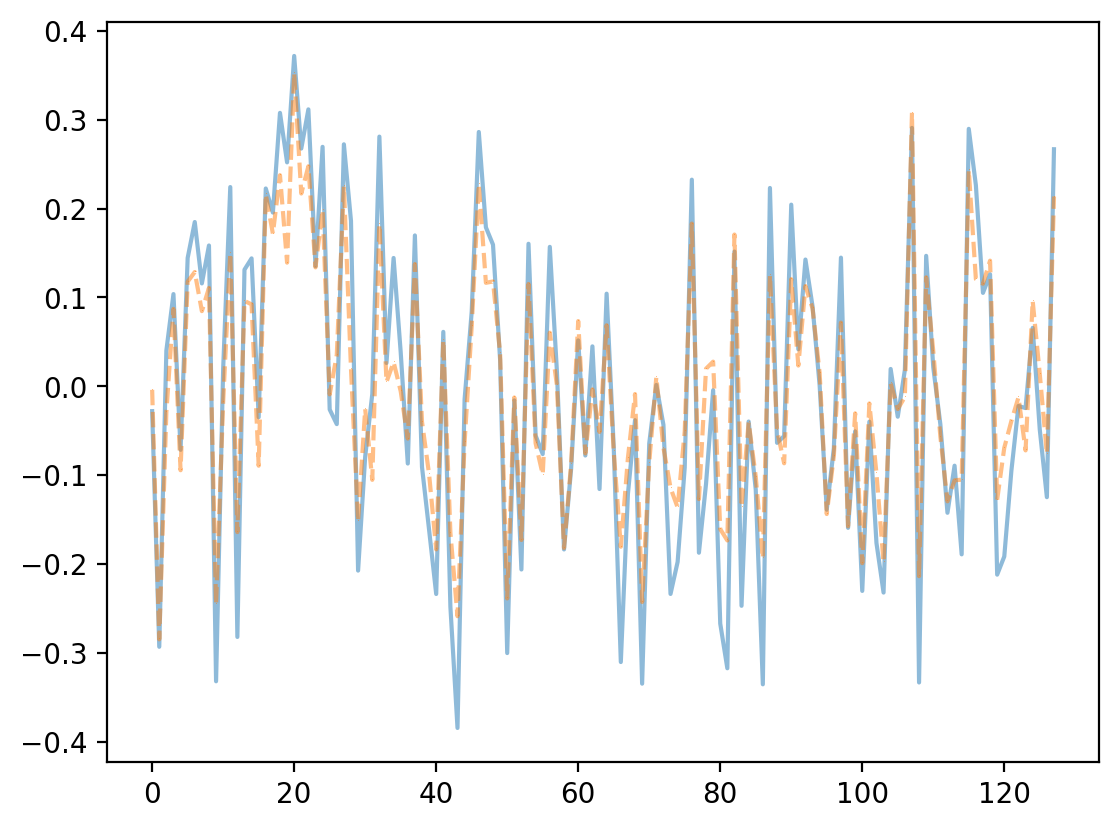

In [ ]:
plt.plot(test_graph_dataset.detach().cpu().numpy(), alpha = 0.5)
plt.plot(test_graph_string.detach().cpu().numpy(), '--,', alpha = 0.5)

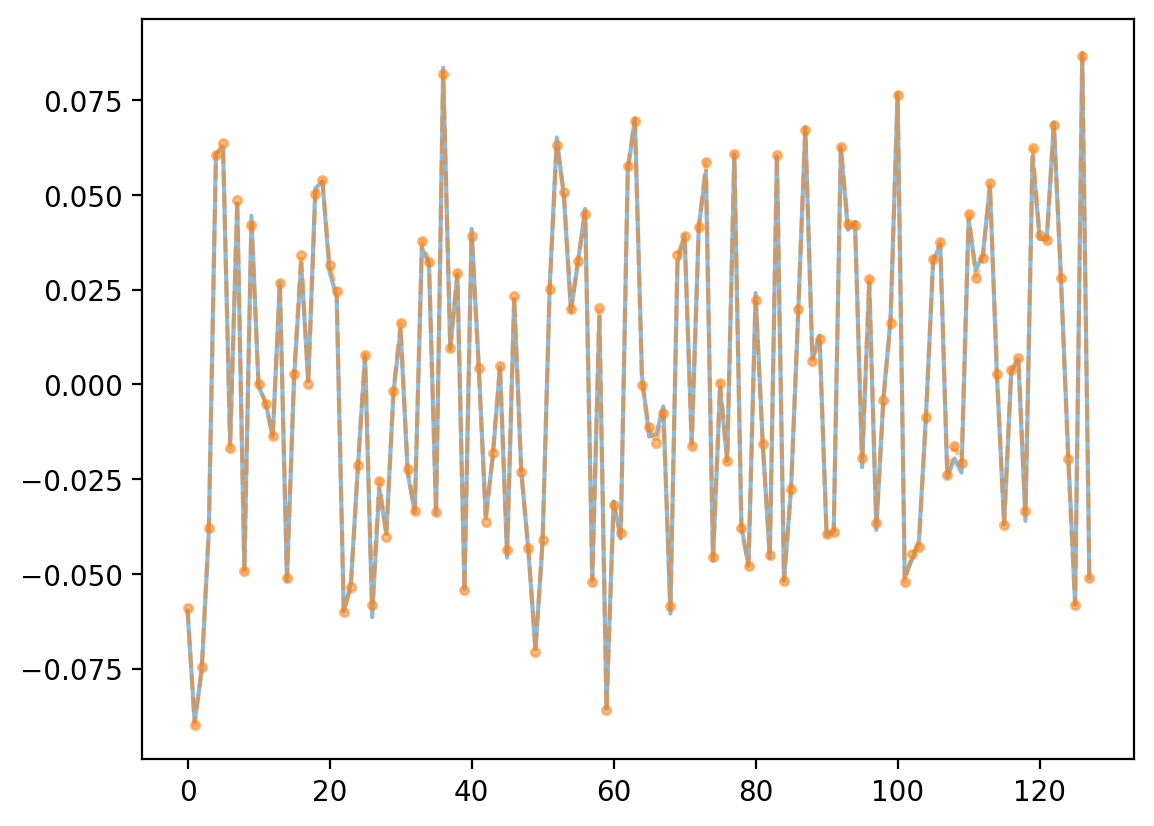

In [ ]:
plt.plot(test_bilstm_dataset[0].detach().cpu().numpy(), alpha = 0.5)
plt.plot(test_bilst_string[0].detach().cpu().numpy(), '--.', alpha = 0.5)

In [ ]:
print(g.segment_bilstm.shape)
print(d['graph_ready_object'].segment_bilstm.shape)

torch.Size([2, 12])
torch.Size([2, 12])


In [ ]:
sorted_x_idxs = np.argsort(y_graph[:,0])
# sorted_x_idxs = np.argsort(y_bilstm[:,0])
print(sorted_x_idxs)
print(chords_list[sorted_x_idxs[0]])
print(chords_list[sorted_x_idxs[-1]])

sorted_y_idxs = np.argsort(y_graph[:,1])
# sorted_y_idxs = np.argsort(y_bilstm[:,1])
print(sorted_y_idxs)
print(chords_list[sorted_y_idxs[0]])
print(chords_list[sorted_y_idxs[-1]])

[492  48  47 ... 244 242 241]
nott_6_[11, 13]<br>b_A:min_@4_m[0, 9, 11, 4]<br>b_A:min_@4_m[8, 9, 7]<br>
gjt_17_[9, 11]<br>b_A#:min11_@4_m[10]<br>b_A#:min11_@4_m[0, 5, 7, 8, 10]<br>
[222 238 233 ... 808 913 921]
gjt_16_[4, 6]<br>b_D:9_@4_m[9]<br>b_D:9_@4_m[9, 3, 4]<br>
nott_35_[13, 15]<br>b_D:min_@1_m[4, 5]<br>G:7_@2_m[2, 5, 7]<br>b_D:min_@1_m[4, 7]<br>G:7_@2_m[0, 2, 11, 5]<br>


In [ ]:
graph_seqs = ''

# print left-most
print('left-most chord sequences:')
graph_seqs += 'left-most chord sequences:' + '\n'
seqs_to_print = 20
printed_seqs = 0
prev_seq = ''
i = 0
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_x_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        graph_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i += 1
print('')
graph_seqs += '\n'

# print right-most
print('right-most chord sequences:')
graph_seqs += 'right-most chord sequences:' + '\n'
printed_seqs = 0
prev_seq = ''
i = -1
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_x_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        graph_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i -= 1
print('')
graph_seqs += '\n'

# print bottom-most
print('bottom-most chord sequences:')
graph_seqs += 'bottom-most chord sequences:' + '\n'
seqs_to_print = 20
printed_seqs = 0
prev_seq = ''
i = 0
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_y_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        graph_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i += 1
print('')
graph_seqs += '\n'

# print top-most
print('top-most chord sequences:')
graph_seqs += 'top-most chord sequences:' + '\n'
seqs_to_print = 20
printed_seqs = 0
prev_seq = ''
i = -1
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_y_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        graph_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i -= 1

left-most chord sequences:
A:min  A:min  
A:maj  A:min  
A:maj  A:maj  
A:min  A:min E:maj A:min  
A:min  A:min C:maj  
E:maj  E:maj  
A:min  C:maj  
C:maj  A:min  
A:min E:maj A:min  A:min E:maj A:min  
A:min  D:min  
D:min  D:maj A:min  
A:min  F:maj  
A:min  G:maj D:maj  
A:min E:maj A:min  D:min  
A:min  G:maj A:min  
D:min  A:min  
G:sus4  G:sus4  
C:maj A:min  D:min  
A#:maj  A#:maj  
G:maj E:maj  A:min  

right-most chord sequences:
A#:min11  A#:min11  
D:min9  G:13  
A:min11  A#:min11  
A:min11  A:min11  
G:13  C:maj7  
A:13  A:min7  
E:min7  A:13  
G:9  G:9  
D#:9  G:9  
D:9  G#:7 G:13  
E:7(b9)  F:9  
F:9  A#:9  
C:9  F:maj9  
A:9  A:9  
D#:maj7  E:13 D#:7  
G#:7 G:13  E:min7 A:7  
G:9  G:7  
G:min7  G:7(#9)  
E:min7 A:9  D:min7 G:7(b9)  
D:min7  G:9  

bottom-most chord sequences:
D:9  D:9  
A:min11  A:min11  
A:min6  A:min6  
G#:7(b13)  G#:7(b13)  
G:13  C:maj7  
A:13  A:min7  
F#:hdim7  E:sus4  
F#:hdim7  B:7(b9)  
D:min9  G:13  
C:maj6  C:maj6  
A:min7  A:min7  
A:min  A:

In [ ]:
print(graph_seqs)

left-most chord sequences:
A:min  A:min  
A:maj  A:min  
A:maj  A:maj  
A:min  A:min E:maj A:min  
A:min  A:min C:maj  
E:maj  E:maj  
A:min  C:maj  
C:maj  A:min  
A:min E:maj A:min  A:min E:maj A:min  
A:min  D:min  
D:min  D:maj A:min  
A:min  F:maj  
A:min  G:maj D:maj  
A:min E:maj A:min  D:min  
A:min  G:maj A:min  
D:min  A:min  
G:sus4  G:sus4  
C:maj A:min  D:min  
A#:maj  A#:maj  
G:maj E:maj  A:min  

right-most chord sequences:
A#:min11  A#:min11  
D:min9  G:13  
A:min11  A#:min11  
A:min11  A:min11  
G:13  C:maj7  
A:13  A:min7  
E:min7  A:13  
G:9  G:9  
D#:9  G:9  
D:9  G#:7 G:13  
E:7(b9)  F:9  
F:9  A#:9  
C:9  F:maj9  
A:9  A:9  
D#:maj7  E:13 D#:7  
G#:7 G:13  E:min7 A:7  
G:9  G:7  
G:min7  G:7(#9)  
E:min7 A:9  D:min7 G:7(b9)  
D:min7  G:9  

bottom-most chord sequences:
D:9  D:9  
A:min11  A:min11  
A:min6  A:min6  
G#:7(b13)  G#:7(b13)  
G:13  C:maj7  
A:13  A:min7  
F#:hdim7  E:sus4  
F#:hdim7  B:7(b9)  
D:min9  G:13  
C:maj6  C:maj6  
A:min7  A:min7  
A:min  A:

In [ ]:
# sorted_x_idxs = np.argsort(y_graph[:,0])
sorted_x_idxs = np.argsort(y_bilstm[:,0])
print(sorted_x_idxs)
print(chords_list[sorted_x_idxs[0]])
print(chords_list[sorted_x_idxs[-1]])

# sorted_y_idxs = np.argsort(y_graph[:,1])
sorted_y_idxs = np.argsort(y_bilstm[:,1])
print(sorted_y_idxs)
print(chords_list[sorted_y_idxs[0]])
print(chords_list[sorted_y_idxs[-1]])

[  2 326 222 ... 208 210 211]
gjt_0_[2, 4]<br>b_F#:hdim7_@4_m[9]<br>b_B:7_@4_m[9, 11]<br>
gjt_15_[7, 9]<br>b_A:min7_@1_m[0]<br>D:7_@1_m[0]<br>G:min7_@1_m[0]<br>C:7_@1_m[0]<br>b_F:maj6_@2_m[5]<br>B:hdim7_@1_m[5]<br>E:7_@1_m[4]<br>
[749 741 120 ... 885 886 154]
nott_22_[8, 10]<br>b_A:min_@1_m[0]<br>E:maj_@1_m[11]<br>A:min_@2_m[9, 2, 4]<br>b_A:min_@1_m[0]<br>E:maj_@1_m[11]<br>A:min_@2_m[0, 9, 4]<br>
gjt_11_[6, 8]<br>b_G:min7_@4_m[5, 7]<br>b_G:7(#9)_@4_m[0, 1]<br>


In [ ]:
bilstm_seqs = ''

# print left-most
print('left-most chord sequences:')
bilstm_seqs += 'left-most chord sequences:' + '\n'
seqs_to_print = 20
printed_seqs = 0
prev_seq = ''
i = 0
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_x_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        bilstm_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i += 1
print('')
bilstm_seqs += '\n'

# print right-most
print('right-most chord sequences:')
bilstm_seqs += 'right-most chord sequences:' + '\n'
printed_seqs = 0
prev_seq = ''
i = -1
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_x_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        bilstm_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i -= 1
print('')
bilstm_seqs += '\n'

# print bottom-most
print('bottom-most chord sequences:')
bilstm_seqs += 'bottom-most chord sequences:' + '\n'
seqs_to_print = 20
printed_seqs = 0
prev_seq = ''
i = 0
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_y_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        bilstm_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i += 1
print('')
bilstm_seqs += '\n'

# print top-most
print('top-most chord sequences:')
bilstm_seqs += 'top-most chord sequences:' + '\n'
seqs_to_print = 20
printed_seqs = 0
prev_seq = ''
i = -1
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_y_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        bilstm_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i -= 1

left-most chord sequences:
F#:hdim7  B:7  
F#:hdim7  B:7(b9)  
D:9  D:9  
A:min6  A:min6  
F#:hdim7  E:sus4  
A:min  A:min  
A:maj6  A:maj6  
B:7  E:min7  
C:7(#11)  B:7  
A:min  C:maj  
F#:sus4  F#:hdim7  
E:sus4  C:maj7  
A:min7  E:sus4  
C:maj  A:min  
B:7(b9)  E:min7  
C:maj7  C:maj7  
D:7  G#:7  
D:7  C:maj  
A:min7  D:7  
C:maj6  C:maj6  

right-most chord sequences:
A:min7 D:7 G:min7 C:7  F:maj6 B:hdim7 E:7  
G:min7 C:7  A:min7 D:7 G:min7 C:7  
G:min7 C:7 C#:dim  D:min7 G:7  
C:maj6 B:min7 E:7  C:maj6 A#:min7 D#:7  
G:maj7 D:min7 G:7  C:maj7 F:9  
G:min7 C:7 C#:dim  D:min7 A#:maj7  
C:maj6 A#:min7 D#:7  G#:maj7 F:min7  
F:maj7 D:min7  G:min7 C:7 C#:dim  
E:maj6 F#:min7 B:7  E:maj6 C:min7 F:7  
A#:maj7 A:aug  G:min7 C:7 B:7  
G:7 C:maj7 E:7  F:maj7 F#:dim7  
D:min7 G:7(b9)  C:maj6 B:min7 E:7  
A:min E:maj A:min  A:min E:maj A:min  
C:maj G:7 C:maj  C:maj F:maj  
G:maj6 C:maj6  G:maj6 D:min7 G:7  
E:maj7 F#:min7 B:sus4  E:maj6 F#:min7 B:7  
A:7 D:7  G:7 C:maj7 E:7  
C:maj F:maj  C

In [ ]:
print(bilstm_seqs)

left-most chord sequences:
F#:hdim7  B:7  
F#:hdim7  B:7(b9)  
D:9  D:9  
A:min6  A:min6  
F#:hdim7  E:sus4  
A:min  A:min  
A:maj6  A:maj6  
B:7  E:min7  
C:7(#11)  B:7  
A:min  C:maj  
F#:sus4  F#:hdim7  
E:sus4  C:maj7  
A:min7  E:sus4  
C:maj  A:min  
B:7(b9)  E:min7  
C:maj7  C:maj7  
D:7  G#:7  
D:7  C:maj  
A:min7  D:7  
C:maj6  C:maj6  

right-most chord sequences:
A:min7 D:7 G:min7 C:7  F:maj6 B:hdim7 E:7  
G:min7 C:7  A:min7 D:7 G:min7 C:7  
G:min7 C:7 C#:dim  D:min7 G:7  
C:maj6 B:min7 E:7  C:maj6 A#:min7 D#:7  
G:maj7 D:min7 G:7  C:maj7 F:9  
G:min7 C:7 C#:dim  D:min7 A#:maj7  
C:maj6 A#:min7 D#:7  G#:maj7 F:min7  
F:maj7 D:min7  G:min7 C:7 C#:dim  
E:maj6 F#:min7 B:7  E:maj6 C:min7 F:7  
A#:maj7 A:aug  G:min7 C:7 B:7  
G:7 C:maj7 E:7  F:maj7 F#:dim7  
D:min7 G:7(b9)  C:maj6 B:min7 E:7  
A:min E:maj A:min  A:min E:maj A:min  
C:maj G:7 C:maj  C:maj F:maj  
G:maj6 C:maj6  G:maj6 D:min7 G:7  
E:maj7 F#:min7 B:sus4  E:maj6 F#:min7 B:7  
A:7 D:7  G:7 C:maj7 E:7  
C:maj F:maj  C

In [ ]:
from ollama import chat
from ollama import ChatResponse

response: ChatResponse = chat(model='qwen2.5-coder:7b', messages=[
  {
    'role': 'user',
    'content': 'Can you commend on sequences of musical chords? \
        For example, which chord sequence is more common: a) G:7 C:maj7 or b)C#:7 C:maj7?',
  },
])
print(response['message']['content'])
# or access fields directly from the response object
# print(response.message.content)

To evaluate whether one chord sequence is more common than the other, we can look at the prevalence of each in popular music and jazz literature. Here are some insights into both sequences:

### Sequence A: G:7 - C:maj7

1. **G:7**: This is a dominant 7th chord, which has been widely used in many genres, particularly in rock and blues.
   - Common uses include resolving to a tonic (C major) or moving to other ii-V-I progressions.

2. **C:maj7**: This is a major 7th chord, often used as the dominant of the dominant.
   - It can be used to extend the length of a phrase or lead into another key center.

### Sequence B: C#:7 - C:maj7

1. **C#:7**: This is an augmented dominant 7th chord. Its use is less common compared to G:7 but still has its applications.
   - It can create a sense of tension and resolve in complex harmonic progressions.
   - Common uses include resolving to a tonic (G# major) or moving to other ii-V-I progressions with an augmented leading tone.

2. **C:maj7**: This is 

In [ ]:
response: ChatResponse = chat(model='qwen2.5-coder:7b', messages=[
  {
    'role': 'user',
    'content': f'You are a music harmony expert and you role is to provide \
    comments on chord progressions that appear within two PCA-projected spaces. \
    These PCA spaces were produced by two models that process symbolic music \
    harmony and we are interested in explaining whether there is something \
    specific that the first two axes represent (left-right and bottom-top). \
    These spaces were formed by the same short chord sequences and we only use \
    the ones on the extreme edges in the analysis.\
    We are interested in understanding if Model 1 or Model 2 \
    have generated more musically meaningful representations and which one is better. \
    Keep in mid that both Models are trained on pieces in C major and A minor \
    and that the sequences they processes are segments of C major - A minor pieces. \
    Below are the Sets positioned in the respective PCA spaces by each model. \
    Here is Set 1: `{bilstm_seqs}`. \n\n \
    Here is Set 2: `{graph_seqs}`.\n \
    If you had to pick a model, who would that be and why?',
  },
])
print(response['message']['content'])

When comparing two models based on their performance in PCA-projected spaces, it is important to consider the distribution of chord sequences across the dimensions represented by the first two axes. Let's analyze the given sets for both Model 1 and Model 2.

### Analysis of Set 1

**Left-most Chord Sequences:**
- The leftmost set contains predominantly minor and major chords with some complex progressions like dim7 and sus4.
- It includes variations in tension and resolution, such as V7-I and ii-V-I progressions.

**Right-most Chord Sequences:**
- The rightmost set also includes a mix of minor and major chords but is slightly more complex with extended chords (e.g., A:min7 D:7 G:min7 C:7).
- It showcases advanced harmonic techniques like pedal points, modulations, and sophisticated voice leading.

**Bottom-most Chord Sequences:**
- The bottom set is dominated by relatively simple progressions, particularly I-V-I and ii-V-I in minor keys.
- It includes some tension-release patterns but 